# ESS optimal feed selection project.



First, let's load the relevant feed data.

In [16]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_parquet('ff26_feed.parquet')
df.head()

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925


In [18]:
df.head(1).transpose()

,0
exchange_timestamp,1773008221031041738
message_type,TRADE
symbol,FVP
price,701.67
trade_count,87
volume,275
sequence_number,1
capture_point,handoff_1
capture_ts,1773008221031185558


##### exchange_timestamp
- time in nanos when the exchange broadcast the message
##### message_type
- what information the message contains. For this project it will always be TRADE
##### symbol
- which instrument the message is for. Can think of them as different stocks
##### price
- the price at which the trade occured
##### trade_count
- how many distinct orders participated in the trade. 
##### volume
- how much volume transacted in the trade
##### sequence_number
- a monotonically increasing ID per symbol to allow distinguising between otherwise identical trades and detecting if we have missed a trade (dropped a packet)
##### capture_point
- which distinct path from the exchange we have used to receive this message 
##### capture_ts
- the nanosecond timestamp at which we received this message. Will deterministically be after the exchange_timestamp. Can be NA if this handoff 

Let's dig into one event just to get a sense of the data

Let's choose this first one arbitrarily

In [19]:
one_event = df.loc[(df.symbol=='FVP')&(df.sequence_number==1)]
one_event

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925
5,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_7,1773008221031183037
6,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_8,1773008221031187254
7,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_9,1773008221031183108
8,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_10,1773008221031187444
9,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021


We can see there are multiple capture points "handoffs" that all potentially received a copy of this message.

All fields are the same apart form the capture point and capture timestamp - they all refer to the same trade at the exchange.

In the world of trading, nanoseconds matter! Receiving the same information as fast as possible can make the difference between getting the trade or not.

The System diagram looks something like the following.

![image.png](attachment:54d52176-4740-449c-a3c7-0358179472a4.png)

In [20]:
one_event.sort_values('capture_ts')

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
9,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021
5,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_7,1773008221031183037
7,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_9,1773008221031183108
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925
6,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_8,1773008221031187254
10,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_12,1773008221031187434


Here, sorting by the capture timestamp we can see that handoff_11 received the message first. 

Note we can infer that some handoffs didn't receive this message at all (as there are missing numbers in the list). This can happen if there is some error in the network, and is known as a 'dropped packet'

Let's look into which capture point wins for each event

In [21]:
fastest_indices = df.groupby(['symbol','sequence_number']).capture_ts.idxmin()
fastest_indices

symbol  sequence_number
AEY     1                       75
        2                      298
        3                      530
        4                      758
        5                      981
                            ...   
ZOP     8351               1473638
        8352               1473768
        8353               1473905
        8354               1474042
        8355               1474185
Name: capture_ts, Length: 686832, dtype: int64

In [22]:
winning_points = df.loc[fastest_indices].reset_index(drop=True)
winning_points

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008229006019680,TRADE,AEY,713.12,19,492,1,handoff_9,1773008229006087819
1,1773008229034913478,TRADE,AEY,713.12,1,100,2,handoff_7,1773008229034932943
2,1773008229043200423,TRADE,AEY,713.12,1,100,3,handoff_11,1773008229043224459
3,1773008229051587773,TRADE,AEY,713.12,1,100,4,handoff_11,1773008229051616950
4,1773008229058967797,TRADE,AEY,713.12,1,15,5,handoff_7,1773008229058993185
...,...,...,...,...,...,...,...,...,...
686827,1773030597018166609,TRADE,ZOP,715.29,1,1,8351,handoff_12,1773030597018218975
686828,1773030597043717925,TRADE,ZOP,715.29,1,1,8352,handoff_6,1773030597043741951
686829,1773030599018156468,TRADE,ZOP,715.29,1,1,8353,handoff_4,1773030599018181704
686830,1773030600006016828,TRADE,ZOP,715.29,1,1,8354,handoff_3,1773030600006043935


Let's confirm that it correctly determines the winner in our manually verified one!

In [23]:
winning_points.loc[(winning_points.symbol=='FVP')&(winning_points.sequence_number==1)]

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
28182,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021


<Axes: title={'center': 'Handoff win rate'}, xlabel='capture_point'>

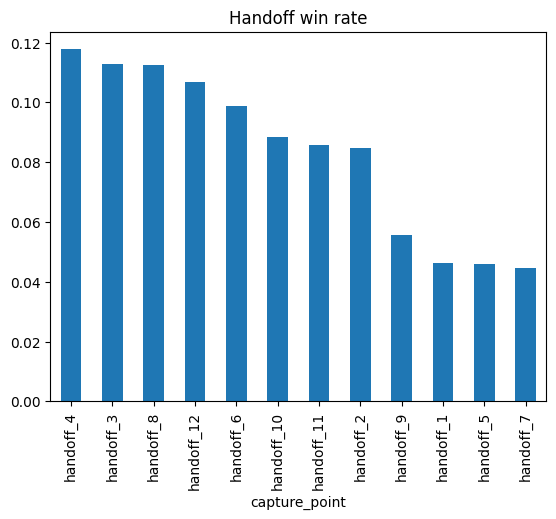

In [24]:
(winning_points.capture_point.value_counts()/winning_points.capture_point.count()).plot(kind='bar',title='Handoff win rate')

So handoff_4 seems to win most often while handoff_7 wins the least.

Let's add a new column called 'latency' to our dataframe that represents the difference between the time the trade occured at the exchange compared to when we received it

In [25]:
df['latency'] = df['capture_ts'] - df['exchange_timestamp']

In [26]:
grouped_latencies = df.groupby('capture_point').latency

In [27]:
grouped_latencies.mean().sort_values()

capture_point
handoff_12    28948.659890
handoff_10    28956.211257
handoff_8     28964.955110
handoff_4     29019.315499
handoff_6     29026.915735
handoff_11    29197.865762
handoff_9     29216.751666
handoff_7     29224.203026
handoff_3     29261.191412
handoff_5     29298.227025
handoff_1     29298.257822
handoff_2     29522.001208
Name: latency, dtype: float64

We can look into some summary statistics for each handoff

In [28]:
grouped_latencies.describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
capture_point,,,,,,,,
handoff_12,670739.0,28948.659890,8687.655320,10555.0,25389.0,27754.0,30381.00,3042618.0
handoff_10,674161.0,28956.211257,8679.492828,10610.0,25398.0,27762.0,30388.00,3042562.0
handoff_8,671371.0,28964.955110,8684.067923,10543.0,25406.0,27772.0,30400.00,3042476.0
handoff_4,672729.0,29019.315499,8728.956626,12375.0,25353.0,27787.0,30529.00,3041529.0
handoff_6,671071.0,29026.915735,8731.981744,12300.0,25362.0,27794.0,30535.00,3041685.0
handoff_11,668565.0,29197.865762,8705.176084,11275.0,25610.0,28003.0,30657.00,3043423.0
handoff_9,668476.0,29216.751666,8706.511466,11222.0,25630.0,28022.0,30674.00,3043438.0
handoff_7,670497.0,29224.203026,8701.849172,11274.0,25638.0,28031.0,30682.00,3043430.0
handoff_3,670131.0,29261.191412,8748.767779,11545.0,25574.0,28036.0,30803.00,3043307.0


Which of these do you think would be most interesting? What are some interesting observations we can make from this table?

### Question 1:
### If you had to select 2 handoffs for feed to connect to your autotrader which 2 would would pick and why?

Per-handoff table (weights W_WIN=0.45, W_COV=0.30, W_MISS=0.25):


,distinct_trades_received,packets_dropped,coverage,miss_rate,win_rate,combined_score
handoff_4,672729,14103,0.979467,0.020533,0.117720,0.997375
handoff_8,671371,15461,0.977489,0.022511,0.112570,0.963245
handoff_3,670131,16701,0.975684,0.024316,0.112869,0.962806
handoff_12,670739,16093,0.976569,0.023431,0.106897,0.927224
handoff_6,671071,15761,0.977053,0.022947,0.098678,0.877332
handoff_10,674161,12671,0.981552,0.018448,0.088464,0.820240
handoff_11,668565,18267,0.973404,0.026596,0.085721,0.793129
handoff_9,668476,18356,0.973274,0.026726,0.055765,0.608903
handoff_1,673062,13770,0.979951,0.020049,0.046206,0.558578
handoff_5,668038,18794,0.972637,0.027363,0.045912,0.547563


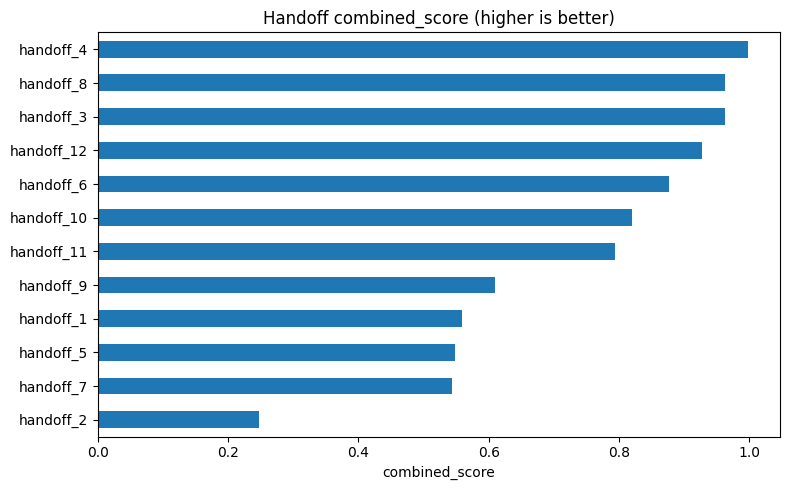


=== Every pair: raw metrics + pair_combined_score (MinMax across pairs only) ===


,handoff_a,handoff_b,coverage_pair,miss_rate_pair,win_rate_pair,win_rate_norm,coverage_norm,miss_rate_norm,low_miss_norm,pair_combined_score
0,handoff_3,handoff_4,0.999537,0.000463,0.230589,1.000000,0.992779,0.007221,0.992779,0.996028
1,handoff_3,handoff_8,0.999474,0.000526,0.225439,0.963267,0.989610,0.010390,0.989610,0.977756
2,handoff_12,handoff_3,0.999442,0.000558,0.219766,0.922796,0.987989,0.012011,0.987989,0.958652
3,handoff_3,handoff_6,0.999451,0.000549,0.211547,0.864171,0.988431,0.011569,0.988431,0.932514
4,handoff_11,handoff_4,0.999490,0.000510,0.203441,0.806356,0.990421,0.009579,0.990421,0.907592
...,...,...,...,...,...,...,...,...,...,...
61,handoff_3,handoff_5,0.979921,0.020079,0.158781,0.487797,0.000000,1.000000,0.000000,0.219509
62,handoff_11,handoff_9,0.980077,0.019923,0.141486,0.364430,0.007884,0.992116,0.007884,0.168330
63,handoff_11,handoff_7,0.980094,0.019906,0.130204,0.283955,0.008769,0.991231,0.008769,0.132602
64,handoff_7,handoff_9,0.980098,0.019902,0.100247,0.070277,0.008990,0.991010,0.008990,0.036569



Best PAIR by pair_combined_score: handoff_3 + handoff_4  |  score=0.996028  |  coverage=0.999537  miss=0.000463  win=0.230589

Top 5 pairs by p99(min latency) — compare to pair_combined_score ranking:


,handoff_a,handoff_b,p99_min_latency,pair_coverage_latency_view
15,handoff_10,handoff_4,61728.54,0.994926
28,handoff_10,handoff_6,61730.00,0.994890
9,handoff_12,handoff_4,61735.00,0.994817
8,handoff_4,handoff_8,61736.03,0.994855
17,handoff_12,handoff_6,61738.53,0.994782


In [29]:
# --- Question 1: handoff scores + **pair_combined_score for every pair** (run after `df` is loaded) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

EVENT_KEYS = ["symbol", "sequence_number"]
df_q = df.dropna(subset=["capture_ts"]).copy()
if "latency" not in df_q.columns:
    df_q["latency"] = df_q["capture_ts"] - df_q["exchange_timestamp"]

n_total = df_q[EVENT_KEYS].drop_duplicates().shape[0]
handoffs = sorted(df_q["capture_point"].unique())

# ---------- Per-handoff combined score (same weights as pairs) ----------
fast_idx = df_q.groupby(EVENT_KEYS, sort=False)["capture_ts"].idxmin()
winning = df_q.loc[fast_idx].reset_index(drop=True)
win_rate = winning["capture_point"].value_counts(normalize=True).rename("win_rate")

seen = {}
for h, g in df_q.groupby("capture_point", sort=False):
    seen[h] = g[EVENT_KEYS].drop_duplicates().shape[0]
seen = pd.Series(seen, name="distinct_trades_received")

coverage = (seen / n_total).rename("coverage")
packets_dropped = (n_total - seen).rename("packets_dropped")
miss_rate = (packets_dropped / n_total).rename("miss_rate")

W_WIN, W_COV, W_MISS = 0.45, 0.30, 0.25


def minmax01(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(1.0, index=s.index)
    return (s - lo) / (hi - lo)


win_n = minmax01(win_rate.reindex(seen.index).fillna(0))
cov_n = minmax01(coverage)
miss_n = minmax01(miss_rate)
low_miss_n = 1.0 - miss_n
combined_score = W_WIN * win_n + W_COV * cov_n + W_MISS * low_miss_n

rank_tbl = pd.DataFrame({
    "distinct_trades_received": seen,
    "packets_dropped": packets_dropped,
    "coverage": coverage,
    "miss_rate": miss_rate,
    "win_rate": win_rate.reindex(seen.index).fillna(0),
    "combined_score": combined_score,
}).sort_values("combined_score", ascending=False)

print("Per-handoff table (weights W_WIN=%.2f, W_COV=%.2f, W_MISS=%.2f):" % (W_WIN, W_COV, W_MISS))
display(rank_tbl)

rank_tbl["combined_score"].sort_values().plot.barh(
    figsize=(8, 5), title="Handoff combined_score (higher is better)"
)
plt.xlabel("combined_score")
plt.tight_layout()
plt.show()

# ---------- pair_combined_score: every pair (k=2), same metric recipe ----------
trades_mi = pd.MultiIndex.from_frame(df_q[EVENT_KEYS].drop_duplicates())
idx_global = df_q.groupby(EVENT_KEYS, sort=False)["latency"].idxmin()
winner_global = df_q.loc[idx_global].set_index(EVENT_KEYS)["capture_point"]
wg = winner_global.reindex(trades_mi)

pair_rows = []
for a, b in combinations(handoffs, 2):
    sub = df_q[df_q["capture_point"].isin([a, b])]
    coverage_pair = sub[EVENT_KEYS].drop_duplicates().shape[0] / n_total
    miss_rate_pair = 1.0 - coverage_pair
    win_rate_pair = float(((wg == a) | (wg == b)).fillna(False).sum() / n_total)
    pair_rows.append(
        {
            "handoff_a": a,
            "handoff_b": b,
            "coverage_pair": coverage_pair,
            "miss_rate_pair": miss_rate_pair,
            "win_rate_pair": win_rate_pair,
        }
    )

pairs_df = pd.DataFrame(pair_rows)
win_pn = minmax01(pairs_df["win_rate_pair"])
cov_pn = minmax01(pairs_df["coverage_pair"])
miss_pn = minmax01(pairs_df["miss_rate_pair"])
low_miss_pn = 1.0 - miss_pn
pairs_df["win_rate_norm"] = win_pn
pairs_df["coverage_norm"] = cov_pn
pairs_df["miss_rate_norm"] = miss_pn
pairs_df["low_miss_norm"] = low_miss_pn
pairs_df["pair_combined_score"] = W_WIN * win_pn + W_COV * cov_pn + W_MISS * low_miss_pn

pairs_df = pairs_df.sort_values("pair_combined_score", ascending=False).reset_index(drop=True)

print("\n=== Every pair: raw metrics + pair_combined_score (MinMax across pairs only) ===")
display(pairs_df)

bestp = pairs_df.iloc[0]
print(
    "\nBest PAIR by pair_combined_score: %s + %s  |  score=%.6f  |  coverage=%.6f  miss=%.6f  win=%.6f"
    % (
        bestp["handoff_a"],
        bestp["handoff_b"],
        bestp["pair_combined_score"],
        bestp["coverage_pair"],
        bestp["miss_rate_pair"],
        bestp["win_rate_pair"],
    )
)

# Optional reference: same pair ranked by p99(min latency) among the two feeds
def min_latency_per_event(hset):
    sub = df_q[df_q["capture_point"].isin(hset)]
    return sub.groupby(EVENT_KEYS, sort=False)["latency"].min()


lat_rows = []
for _, r in pairs_df.iterrows():
    a, b = r["handoff_a"], r["handoff_b"]
    m = min_latency_per_event([a, b])
    lat_rows.append(
        {
            "handoff_a": a,
            "handoff_b": b,
            "p99_min_latency": float(m.quantile(0.99)),
            "pair_coverage_latency_view": m.shape[0] / n_total,
        }
    )
pairs_latency = pd.DataFrame(lat_rows).sort_values(
    ["p99_min_latency", "pair_coverage_latency_view"], ascending=[True, False]
)
print("\nTop 5 pairs by p99(min latency) — compare to pair_combined_score ranking:")
display(pairs_latency.head(5))



### Question 2:
### Currently your autotrader only supports 2 handoffs, but what gain would we get from adding additional handoffs? What would be an optimal number?

Each row is the **prefix** of handoffs sorted by individual combined_score (Q1 recipe). Only **H** joint evaluations (not all C(H,k) subsets).


,k,label,subset,coverage_raw,miss_rate_raw,win_rate_raw,raw_combined,added_handoff,delta_raw_combined,cumulative_gain_raw
0,1,group_of_1,"(handoff_4,)",0.979467,0.020533,0.117720,0.591681,handoff_4,NaN,0.000000
1,2,pair,"(handoff_4, handoff_8)",0.994855,0.005145,0.230291,0.650801,handoff_8,0.059120,0.059120
2,3,triplet,"(handoff_4, handoff_8, handoff_3)",0.999917,0.000083,0.343160,0.704376,handoff_3,0.053575,0.112695
3,4,quartet,"(handoff_4, handoff_8, handoff_3, handoff_12)",0.999917,0.000083,0.450056,0.752480,handoff_12,0.048103,0.160799
4,5,group_of_5,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",0.999917,0.000083,0.548734,0.796885,handoff_6,0.044405,0.205204
5,6,group_of_6,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",0.999917,0.000083,0.637198,0.836693,handoff_10,0.039809,0.245013
6,7,group_of_7,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",0.999999,0.000001,0.722919,0.875313,handoff_11,0.038619,0.283632
7,8,group_of_8,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",0.999999,0.000001,0.778684,0.900407,handoff_9,0.025094,0.308726
8,9,group_of_9,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",1.000000,0.000000,0.824890,0.921201,handoff_1,0.020794,0.329520
9,10,group_of_10,"(handoff_4, handoff_8, handoff_3, handoff_12, ...",1.000000,0.000000,0.870802,0.941861,handoff_5,0.020661,0.350180



Individual ranking (handoff -> combined_score):


,individual_combined_score
capture_point,
handoff_4,0.997375
handoff_8,0.963245
handoff_3,0.962806
handoff_12,0.927224
handoff_6,0.877332
handoff_10,0.820240
handoff_11,0.793129
handoff_9,0.608903
handoff_1,0.558578



PAIR (k=2): subset=('handoff_4', 'handoff_8')  raw_combined=0.650801  coverage=0.994855 miss=0.005145 win=0.230291

TRIPLET (k=3): subset=('handoff_4', 'handoff_8', 'handoff_3')  raw_combined=0.704376  coverage=0.999917 miss=0.000083 win=0.343160

QUARTET (k=4): subset=('handoff_4', 'handoff_8', 'handoff_3', 'handoff_12')  raw_combined=0.752480  coverage=0.999917 miss=0.000083 win=0.450056


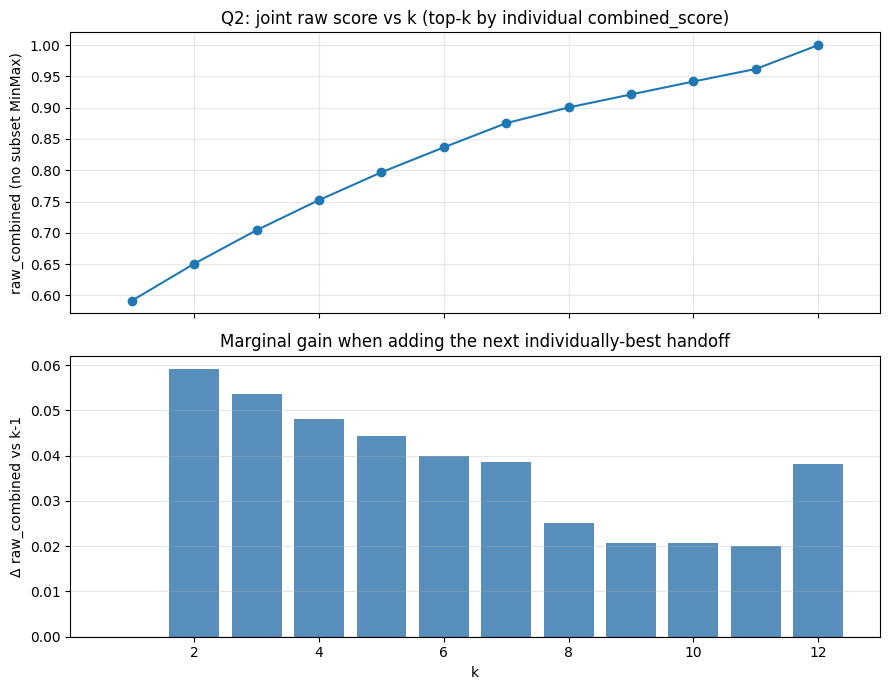

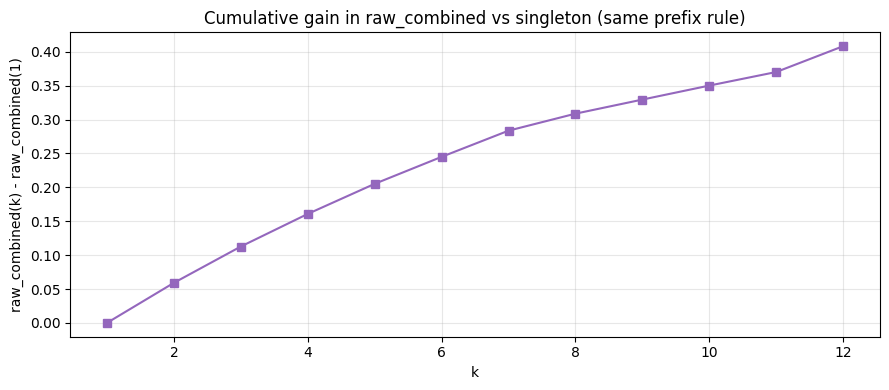

In [30]:
# --- Question 2: joint metrics vs k WITHOUT enumerating all subsets ---
# Build the k-handoff set as the **top-k handoffs by individual combined_score** (same weights
# and MinMax recipe as Question 1 on *handoffs only*). At each k you only evaluate **one** set:
#   S_k = { the k highest individual-score handoffs }.
#
# For that set S_k we still compute the same three joint scalars as pair_combined_score:
#   coverage_S, miss_rate_S = 1 - coverage_S, win_rate_S (global min-latency winner in S_k)
# and the **raw** weighted score (no MinMax across subsets — there is only one set per k):
#   raw_combined = W_WIN*win + W_COV*coverage + W_MISS*(1 - miss_rate)
#
# This avoids ~4095 subset evaluations; complexity is **O(H * n_total)** for win_rate scans.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EVENT_KEYS = ["symbol", "sequence_number"]
df_q = df.dropna(subset=["capture_ts"]).copy()
if "latency" not in df_q.columns:
    df_q["latency"] = df_q["capture_ts"] - df_q["exchange_timestamp"]

df_q = df_q.copy()
df_q["_tid"] = df_q.groupby(EVENT_KEYS, sort=False).ngroup()
n_total = int(df_q["_tid"].max()) + 1
handoffs = sorted(df_q["capture_point"].unique())
H = len(handoffs)
h_index = {h: i for i, h in enumerate(handoffs)}

h_to_tids = {h: set(grp["_tid"].unique()) for h, grp in df_q.groupby("capture_point", sort=False)}

idx_g = df_q.groupby(EVENT_KEYS, sort=False)["latency"].idxmin()
win_df = df_q.loc[idx_g, ["_tid", "capture_point"]].drop_duplicates("_tid")
winner_tid = np.full(n_total, -1, dtype=np.int16)
for tid, h in zip(win_df["_tid"].to_numpy(), win_df["capture_point"].to_numpy()):
    winner_tid[tid] = np.int16(h_index[h])

W_WIN, W_COV, W_MISS = 0.45, 0.30, 0.25


def minmax01(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(1.0, index=s.index)
    return (s - lo) / (hi - lo)


# ----- Individual handoff combined_score (same construction as Q1) -----
fast_idx = df_q.groupby(EVENT_KEYS, sort=False)["capture_ts"].idxmin()
winning = df_q.loc[fast_idx].reset_index(drop=True)
win_rate_h = winning["capture_point"].value_counts(normalize=True).rename("win_rate")

seen_h = {}
for h, g in df_q.groupby("capture_point", sort=False):
    seen_h[h] = g[EVENT_KEYS].drop_duplicates().shape[0]
seen_h = pd.Series(seen_h)
coverage_h = seen_h / n_total
miss_h = 1.0 - coverage_h

win_n = minmax01(win_rate_h.reindex(handoffs).fillna(0))
cov_n = minmax01(coverage_h.reindex(handoffs).fillna(0))
miss_n = minmax01(miss_h.reindex(handoffs).fillna(0))
low_miss_n = 1.0 - miss_n
individual_score = W_WIN * win_n + W_COV * cov_n + W_MISS * low_miss_n
individual_score = individual_score.reindex(handoffs)

# Order: add next handoff strictly by individual combined_score (descending)
order = list(individual_score.sort_values(ascending=False).index)


def subset_raw_metrics(S):
    union = set()
    for h in S:
        union |= h_to_tids[h]
    coverage = len(union) / n_total
    miss_rate = 1.0 - coverage
    S_idx = np.fromiter((h_index[h] for h in S), dtype=np.int16, count=len(S))
    win_rate = float(np.mean(np.isin(winner_tid, S_idx)))
    return coverage, miss_rate, win_rate


summary_rows = []
for k in range(1, H + 1):
    S_k = tuple(order[:k])
    cov, miss, win = subset_raw_metrics(S_k)
    raw_combined = W_WIN * win + W_COV * cov + W_MISS * (1.0 - miss)
    summary_rows.append(
        {
            "k": k,
            "label": {2: "pair", 3: "triplet", 4: "quartet"}.get(k, f"group_of_{k}"),
            "subset": S_k,
            "coverage_raw": float(cov),
            "miss_rate_raw": float(miss),
            "win_rate_raw": float(win),
            "raw_combined": float(raw_combined),
            "added_handoff": order[k - 1],
        }
    )

summary = pd.DataFrame(summary_rows)
summary["delta_raw_combined"] = summary["raw_combined"].diff()
summary["cumulative_gain_raw"] = summary["raw_combined"] - summary["raw_combined"].iloc[0]

print(
    "Each row is the **prefix** of handoffs sorted by individual combined_score (Q1 recipe). "
    "Only **H** joint evaluations (not all C(H,k) subsets)."
)
display(summary)

print("\nIndividual ranking (handoff -> combined_score):")
display(individual_score.sort_values(ascending=False).to_frame("individual_combined_score"))

for kk in (2, 3, 4):
    row = summary.loc[summary["k"] == kk].iloc[0]
    print(
        f"\n{row['label'].upper()} (k={kk}): subset={row['subset']}  raw_combined={row['raw_combined']:.6f}  "
        f"coverage={row['coverage_raw']:.6f} miss={row['miss_rate_raw']:.6f} win={row['win_rate_raw']:.6f}"
    )

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(summary["k"], summary["raw_combined"], marker="o", color="tab:blue")
axes[0].set_ylabel("raw_combined (no subset MinMax)")
axes[0].set_title("Q2: joint raw score vs k (top-k by individual combined_score)")
axes[0].grid(True, alpha=0.3)

axes[1].bar(summary["k"], summary["delta_raw_combined"].fillna(0.0), color="steelblue", alpha=0.9)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Δ raw_combined vs k-1")
axes[1].set_title("Marginal gain when adding the next individually-best handoff")
axes[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(9, 4))
ax.plot(summary["k"], summary["cumulative_gain_raw"], marker="s", color="tab:purple")
ax.set_xlabel("k")
ax.set_ylabel("raw_combined(k) - raw_combined(1)")
ax.set_title("Cumulative gain in raw_combined vs singleton (same prefix rule)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Reference: exhaustive subset search (slow) was removed; use Q1 pair table for true pair optimum.



### Question 3
### Is there anything else interesting you found in the data?

Copies per trade (expect up to 12 if every path gets every trade):


count    686832.000000
mean         11.287941
std           1.058161
min           1.000000
25%          11.000000
50%          11.000000
75%          12.000000
max          12.000000
dtype: float64

Fraction of trades missing at least one handoff copy: 0.5095


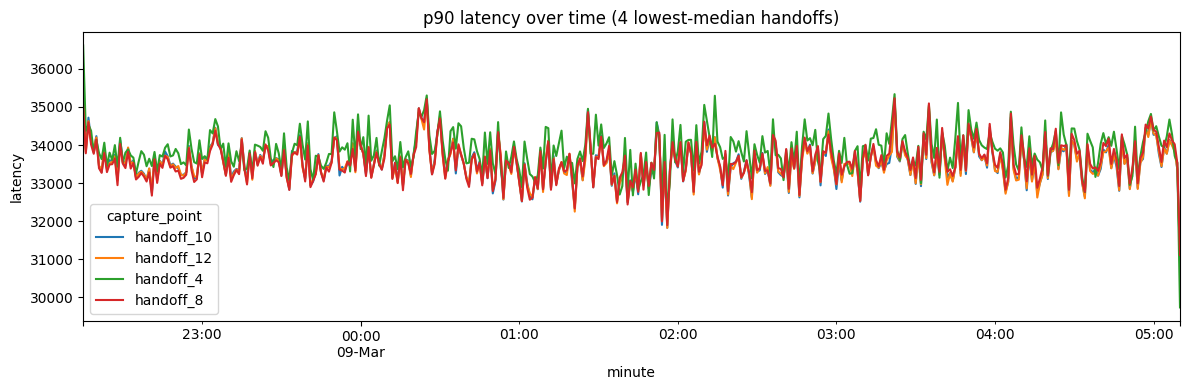

Top 15 (capture_point, symbol) by p99 latency:


,capture_point,symbol,p99_latency
34,handoff_2,LJY,66206.76
38,handoff_6,LJY,66146.60
36,handoff_4,LJY,66105.90
37,handoff_5,LJY,64954.50
35,handoff_3,LJY,64914.83
33,handoff_1,LJY,64861.61
116,handoff_5,RDG,64802.52
112,handoff_1,RDG,64781.56
222,handoff_5,ZOP,64751.48
114,handoff_3,RDG,64747.16


Largest single-trade volumes (first row per trade):


symbol  sequence_number
ZOP     145                4999
LJY     43                 4999
ZOP     143                4000
LJY     41                 4000
IQA     1                  3047
TRK     1                  2766
LJY     2723               2278
ZOP     7933               2278
FVP     25742              2000
AEY     1961               2000
Name: volume, dtype: int64

In [31]:
# --- Question 3: extra angles (drops, time, tails) ---
import pandas as pd
import matplotlib.pyplot as plt

EVENT_KEYS = ["symbol", "sequence_number"]
df_q = df.dropna(subset=["capture_ts"]).copy()
if "latency" not in df_q.columns:
    df_q["latency"] = df_q["capture_ts"] - df_q["exchange_timestamp"]

n_handoffs = df_q["capture_point"].nunique()
rows_per_trade = df_q.groupby(EVENT_KEYS, sort=False).size()
print("Copies per trade (expect up to", n_handoffs, "if every path gets every trade):")
display(rows_per_trade.describe())
frac_incomplete = float((rows_per_trade < n_handoffs).mean())
print("Fraction of trades missing at least one handoff copy:", round(frac_incomplete, 4))

# Time-of-day: p90 latency by minute for a few handoffs with lowest median latency
df_q["exchange_dt"] = pd.to_datetime(
    df_q["exchange_timestamp"], unit="ns", utc=True, errors="coerce"
)
df_q["minute"] = df_q["exchange_dt"].dt.floor("min")

med_by_h = df_q.groupby("capture_point")["latency"].median().sort_values()
sample_h = list(med_by_h.head(4).index)
p90_ts = (
    df_q[df_q["capture_point"].isin(sample_h)]
    .groupby(["minute", "capture_point"])["latency"]
    .quantile(0.90)
    .unstack("capture_point")
)
ax = p90_ts.plot(figsize=(12, 4), title="p90 latency over time (4 lowest-median handoffs)")
ax.set_ylabel("latency")
plt.tight_layout()
plt.show()

# Worst (handoff, symbol) tails — interesting outliers
tail = (
    df_q.groupby(["capture_point", "symbol"], sort=False)["latency"]
    .quantile(0.99)
    .reset_index(name="p99_latency")
    .sort_values("p99_latency", ascending=False)
)
print("Top 15 (capture_point, symbol) by p99 latency:")
display(tail.head(15))

# Largest single-trade volumes (often worth mentioning in write-up)
vol_event = df_q.groupby(EVENT_KEYS, sort=False)["volume"].first().sort_values(ascending=False)
print("Largest single-trade volumes (first row per trade):")
display(vol_event.head(10))

### Some ideas to get you started:
##### Latency
##### Dropped packets
##### Time of day
##### Network traffic